# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


In [3]:
# your code here

---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


In [4]:
# your code here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import sklearn

In [6]:
# your code here
def load_data(filepath):
    df = pd.read_csv(filepath)
    return df

In [7]:
# your code here
df = load_data('data/Telco-customer-churn-dataset.csv')

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


<h3><strong>Converting dtype for TotalCharges</strong></h3>

In [11]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

In [12]:
df['TotalCharges'].isna().sum()

np.int64(11)

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [14]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?
- What is y (your target variable)?
- What probability distribution naturally models the target? What does that tell you about the right loss function?
- What is your hypothesis class (model family)?
- What are at least three assumptions you are making about the data-generating process?
- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


**Your formulation here:**

- X (feature space): 
- y (target variable): Churn
- Probability distribution of y: 
- Natural loss function: 
- Hypothesis class: 
- Assumption 1: 
- Assumption 2: 
- Assumption 3: 
- Sources of uncertainty: 

---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


In [15]:
# your code here
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

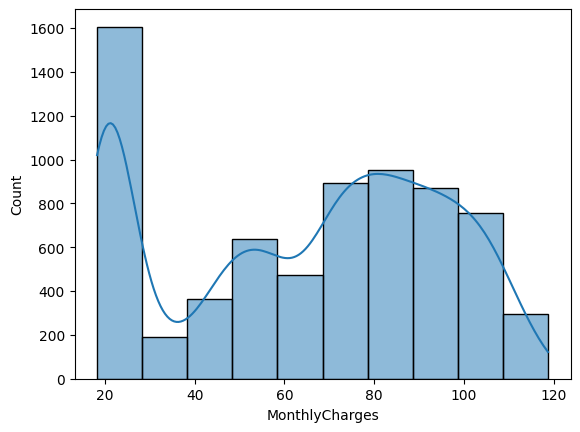

In [16]:
# your code here
sns.histplot(data=df, x='MonthlyCharges', kde=True, bins=10)

<Axes: xlabel='TotalCharges', ylabel='Count'>

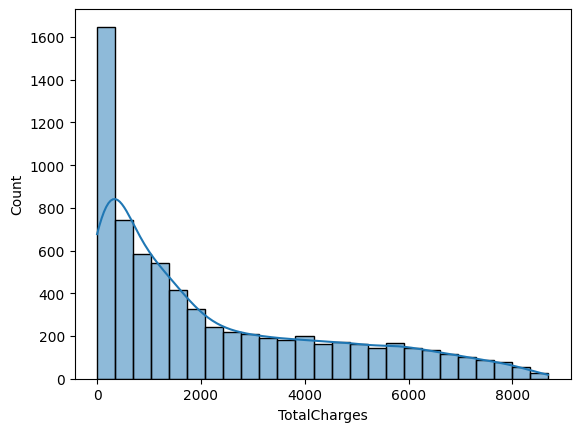

In [17]:
# your code here
sns.histplot(data=df, x='TotalCharges', kde=True)

<Axes: xlabel='tenure', ylabel='Count'>

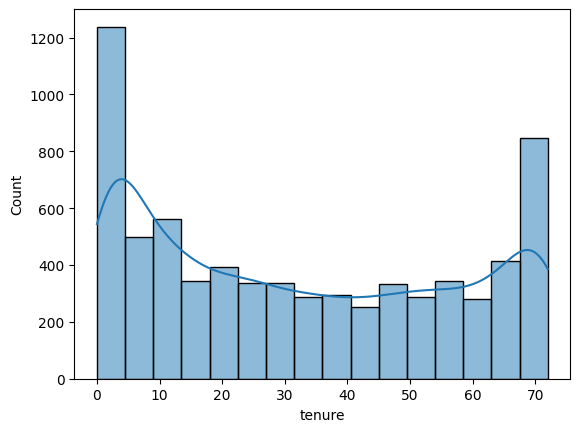

In [18]:
sns.histplot(data=df, x='tenure', kde=True)

---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


In [19]:
# your code here
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

In [20]:
dummy_model = DummyClassifier(strategy='most_frequent')
dummy_model.fit(X=df['MonthlyCharges'], y=df['Churn'])

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [21]:
predict = dummy_model.predict([12, 13, 55, 67, 552])
print(predict)

[0 0 0 0 0]


In [22]:
print(classification_report(df['Churn'][:5], y_pred=predict))

              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       0.00      0.00      0.00         2

    accuracy                           0.60         5
   macro avg       0.30      0.50      0.38         5
weighted avg       0.36      0.60      0.45         5



c:\Users\NIC\OneDrive\Desktop\FuseMachines\week-4\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NIC\OneDrive\Desktop\FuseMachines\week-4\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\NIC\OneDrive\Desktop\FuseMachines\week-4\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

---

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

---

# Block 2 — Preprocessing

Preprocessing was covered in Week 1. We keep this block minimal — working code only.

---

## 2.1 Encode, Split, Scale

### Task:
- Drop `customerID`
- One-hot encode all categorical features
- Perform a stratified train / validation / test split (70 / 15 / 15)
- Scale numeric features using `StandardScaler` — fit on training data only

### Questions:
- Why do we use stratified splitting for a churn dataset?
- Why do we fit the scaler on training data only?
- What would happen if we scaled before splitting?

### Hint:
- `pd.get_dummies(df, drop_first=True)` one-hot encodes all object columns
- `train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)`
- Then split the 30% remainder 50/50 for val and test
- `scaler.fit(X_train)` → `scaler.transform(X_train)`, `scaler.transform(X_val)`, `scaler.transform(X_test)`

### Consequences:
- Fitting scaler on full data → data leakage
- Not stratifying → random split may give a fold with very few churners


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()

In [25]:
df.drop(columns=['customerID'], inplace=True)

In [26]:
cleaned_df = pd.get_dummies(df, drop_first=True, dtype='int')

In [27]:
target = cleaned_df['Churn']
features = cleaned_df.drop(columns=['Churn'])

Splitting data into training set and (validation and testing) set

In [28]:
# your code here
x_train, x_val_test, y_train, y_val_test = train_test_split(features, target, test_size=0.3, stratify=target, random_state=42)

In [29]:
print(f'X_train: {x_train.shape}, Y_train: {y_train.shape}, X_val_test: {x_val_test.shape}, Y_val_test: {y_val_test.shape}')

X_train: (4930, 30), Y_train: (4930,), X_val_test: (2113, 30), Y_val_test: (2113,)


Splitting the validation and testing set into validation set and testing set (50/50)

In [30]:
x_val, x_test, y_val, y_test = train_test_split(x_val_test, y_val_test, stratify=y_val_test, random_state=42, test_size=0.5)

In [31]:
# your code here
print(f'X_val: {x_val.shape}, Y_val: {y_val.shape}, X_test: {x_test.shape}, Y_test: {y_test.shape}')

X_val: (1056, 30), Y_val: (1056,), X_test: (1057, 30), Y_test: (1057,)


Fitting the scaler to <b>training set</b> only such that the train, test, validate set can be transformed based on nature of training set. <strong>We do this to avoid <i>data leakage</i></strong>

In [32]:
num_cols = ['MonthlyCharges', 'TotalCharges', 'tenure']

In [33]:
# Keep originals, then create scaled copies (do not overwrite originals)
x_train_original = x_train.copy()
x_val_original = x_val.copy()
x_test_original = x_test.copy()

# Fit scaler on training originals and produce scaled datasets
scaler.fit(x_train_original[num_cols])
x_train_scaled = x_train_original.copy()
x_train_scaled[num_cols] = scaler.transform(x_train_original[num_cols])
x_val_scaled = x_val_original.copy()
x_val_scaled[num_cols] = scaler.transform(x_val_original[num_cols])
x_test_scaled = x_test_original.copy()
x_test_scaled[num_cols] = scaler.transform(x_test_original[num_cols])

---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / … | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
- What loss function does each model optimise?
- Which model trains fastest? Does that surprise you?

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


In [34]:
# your code here
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_curve, auc, precision_recall_curve, average_precision_score

In [35]:
# your code here
logisticModel = LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42)
# train on scaled features
logisticModel.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [36]:
y_predicted = logisticModel.predict(x_test_scaled)
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.90      0.74      0.81       776
           1       0.52      0.78      0.62       281

    accuracy                           0.75      1057
   macro avg       0.71      0.76      0.72      1057
weighted avg       0.80      0.75      0.76      1057



In [37]:
ridge = RidgeClassifier()

ridge.fit(x_train_scaled, y_train)
y_pred_ridge = ridge.predict(x_test_scaled)

In [38]:
sgd = SGDClassifier(loss="log_loss", max_iter=1000, random_state=42)

sgd.fit(x_train_scaled, y_train)
y_pred_sgd = sgd.predict(x_test_scaled)

---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


In [39]:
# your code here
def evaluate(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=1),
        "Recall": recall_score(y_true, y_pred, pos_label=1),
        "F1-score": f1_score(y_true, y_pred, pos_label=1)
    }

results = []

results.append(evaluate("Logistic Regression", y_test, y_predicted))
results.append(evaluate("Ridge Classifier", y_test, y_pred_ridge))
results.append(evaluate("SGDClassifier", y_test, y_pred_sgd))

df_results = pd.DataFrame(results)

print(df_results)

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.747398   0.516509  0.779359  0.621277
1     Ridge Classifier  0.794702   0.656863  0.476868  0.552577
2        SGDClassifier  0.802271   0.665138  0.516014  0.581162


In [40]:
# your code here

---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
- At what threshold does your model maximise F1?
- Why does the PR curve tell you more than the ROC curve for this problem?
- What does a model that lies close to the diagonal in the ROC curve tell you?

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o


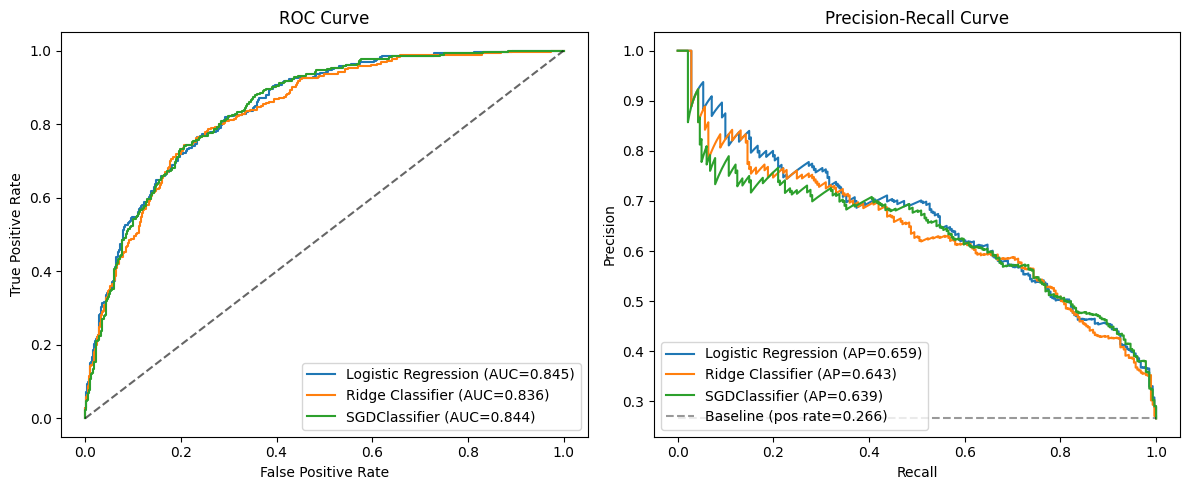

                 Model   ROC_AUC    PR_AUC
0  Logistic Regression  0.844875  0.659403
1     Ridge Classifier  0.836464  0.642679
2        SGDClassifier  0.844013  0.638888


In [41]:
# Compare ROC and Precision-Recall for all trained models (single cell)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

models = {
    'Logistic Regression': logisticModel,
    'Ridge Classifier': ridge,
    'SGDClassifier': sgd
}
results = []
plt.figure(figsize=(12,5))
ax1 = plt.subplot(1,2,1)  # ROC
ax2 = plt.subplot(1,2,2)  # Precision-Recall
colors = ['tab:blue', 'tab:orange', 'tab:green']

for (name, model), color in zip(models.items(), colors):
    # always score on scaled test set
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(x_test_scaled)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(x_test_scaled)
    else:
        y_score = model.predict(x_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_auc = average_precision_score(y_test, y_score)

    ax1.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})', color=color)
    ax2.plot(recall, precision, label=f'{name} (AP={pr_auc:.3f})', color=color)

    results.append({'Model': name, 'ROC_AUC': roc_auc, 'PR_AUC': pr_auc})

ax1.plot([0,1], [0,1], 'k--', alpha=0.6)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend(loc='lower right')

# Baseline for PR is the prevalence of the positive class
pos_rate = y_test.mean()
ax2.plot([0,1], [pos_rate, pos_rate], 'k--', alpha=0.4, label=f'Baseline (pos rate={pos_rate:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

import pandas as pd
print(pd.DataFrame(results).sort_values('PR_AUC', ascending=False).reset_index(drop=True))

### Logistic Regression was found to be the best model for our task

---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
- How do you identify the top 200 highest-risk customers?
- What precision do you achieve at that threshold?
- How does this compare to the default threshold of 0.5?

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


In [42]:
# your code here
predicted_probab = sorted(logisticModel.predict_proba(x_test_scaled)[:, 1], reverse= True)   #sorted probability in descending order
threshold = predicted_probab[199]
probab_gt_threshold = (predicted_probab >= threshold).astype(int)    #setting threshold as probability at 200th position
probab_gt_threshold


array([1, 1, 1, ..., 0, 0, 0], shape=(1057,))

In [43]:
precision_top_200 = precision_score(y_test, probab_gt_threshold)
recall_top_200 = recall_score(y_test, probab_gt_threshold)
f1_top_200 = f1_score(y_test, probab_gt_threshold)

In [44]:
y_pred_05 = (np.array(predicted_probab) >= 0.5).astype(int)    #setting threshold = 0.5

precision_05 = precision_score(y_test, y_pred_05)
recall_05 = recall_score(y_test, y_pred_05)
f1_05 = f1_score(y_test, y_pred_05)

In [45]:
print("===== THRESHOLD COMPARISON =====\n")

print("Threshold = 0.5")
print(f"Precision: {precision_05:.4f}")
print(f"Recall   : {recall_05:.4f}")
print(f"F1 Score : {f1_05:.4f}")

print("\n-----------------------------\n")

print("Top 200 Strategy")
print(f"Precision: {precision_top_200:.4f}")
print(f"Recall   : {recall_top_200:.4f}")
print(f"F1 Score : {f1_top_200:.4f}")

===== THRESHOLD COMPARISON =====

Threshold = 0.5
Precision: 0.2736
Recall   : 0.4128
F1 Score : 0.3291

-----------------------------

Top 200 Strategy
Precision: 0.2750
Recall   : 0.1957
F1 Score : 0.2287


---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


In [46]:
# your code here
def predict_top_features(model, top_n = 10):
    print(f"Model Name: {model}")
    top_10_features = pd.Series(model.coef_[0]).abs().nlargest(top_n)
    # use original (unscaled) dataframe to fetch human-friendly column names
    equivalent_cols = list(x_test_original.columns[top_10_features.index])
    print(f"Top 10 features: {top_10_features}")
    print()
    print(f"Equivalent columns: {equivalent_cols}")

    # Draw with a wider figure and smaller xtick font so long column names fit
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(x=equivalent_cols, y=top_10_features, label="Features Weights", color='g', ax=ax)
    ax.set_xlabel("Features")
    ax.set_ylabel("Weights")
    # reduce fontsize and align right so long names are readable
    ax.set_xticklabels(equivalent_cols, rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()

Model Name: LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
Top 10 features: 25    1.376520
1     1.230455
10    0.958544
24    0.745924
3     0.608389
28    0.396541
23    0.391348
26    0.382495
2     0.375521
13    0.370136
dtype: float64

Equivalent columns: ['Contract_Two year', 'tenure', 'InternetService_Fiber optic', 'Contract_One year', 'TotalCharges', 'PaymentMethod_Electronic check', 'StreamingMovies_Yes', 'PaperlessBilling_Yes', 'MonthlyCharges', 'OnlineSecurity_Yes']


C:\Users\NIC\AppData\Local\Temp\ipykernel_8472\2354750931.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(equivalent_cols, rotation=45, ha='right', fontsize=8)


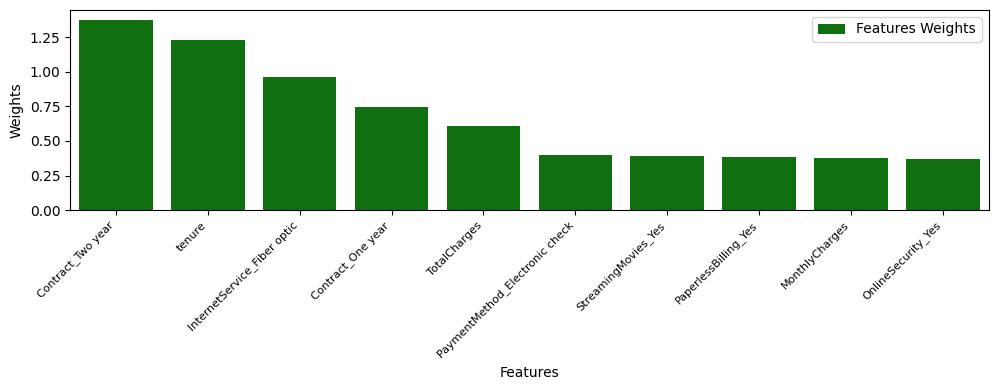

In [47]:
# your code here
predict_top_features(model=logisticModel)

Model Name: SGDClassifier(loss='log_loss', random_state=42)
Top 10 features: 10    1.382849
1     1.378786
25    1.295329
2     0.828873
24    0.715944
23    0.665974
3     0.602077
21    0.592832
9     0.528817
7     0.415656
dtype: float64

Equivalent columns: ['InternetService_Fiber optic', 'tenure', 'Contract_Two year', 'MonthlyCharges', 'Contract_One year', 'StreamingMovies_Yes', 'TotalCharges', 'StreamingTV_Yes', 'MultipleLines_Yes', 'PhoneService_Yes']


C:\Users\NIC\AppData\Local\Temp\ipykernel_8472\2354750931.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(equivalent_cols, rotation=45, ha='right', fontsize=8)


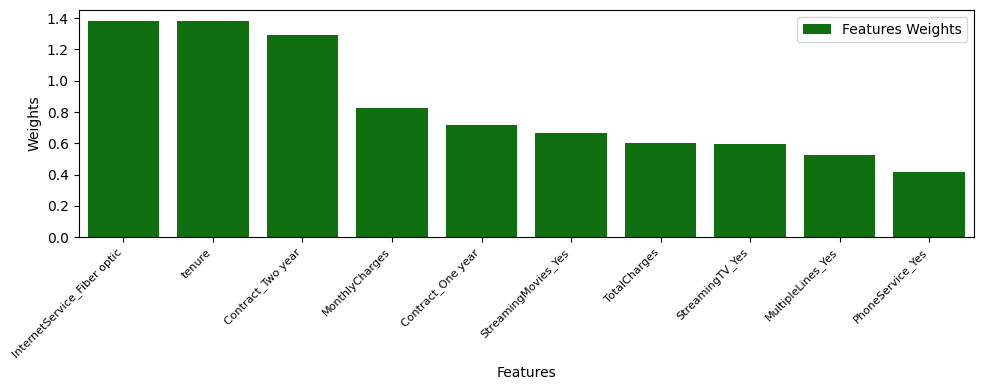

In [48]:
predict_top_features(model=sgd)

| Feature | SGD Classifier | Logistic Regression |
|---|---|---|
| InternetService_Fiber optic | 1.38 | 0.97 |
| tenure | 1.38 | 1.24 |
| Contract_Two year | 1.28 | 1.35 |
| MonthlyCharges | 0.82 | 0.37 |
| Contract_One year | 0.70 | 0.74 |
| StreamingMovies_Yes | 0.65 | 0.39 |
| TotalCharges | 0.60 | 0.62 |
| StreamingTV_Yes | 0.60 | N/A |
| MultipleLines_Yes | 0.51 | N/A |
| PhoneService_Yes | 0.41 | N/A |
| PaymentMethod_Electronic check | N/A | 0.39 |
| PaperlessBilling_Yes | N/A | 0.38 |
| OnlineSecurity_Yes | N/A | 0.36 |
| Weight Range | 0.41 - 1.38 | 0.36 - 1.35 |
| Top Feature | InternetService_Fiber optic, tenure (tied) | Contract_Two year |
| Optimization | Approximates via stochastic gradient | Finds exact global optimum |
| Stability | Less stable across runs | Stable and reproducible |
| Interpretability | Moderate | High |
| Best suited for | Large-scale or streaming data | Small to medium datasets |
| Recommended | No | Yes |

---

## 3.6 Batch GD vs SGD

### Task:
Compare `LogisticRegression` vs `SGDClassifier(loss='log_loss')`.  
Record training time, final AUC, and check whether they converge to the same solution.

### Questions:
- Do they produce the same predictions? Same coefficients?
- Which is faster?
- Under what conditions would you prefer SGD?

### Hint:
- `np.allclose(lr.coef_, sgd.coef_, atol=0.15)` checks approximate coefficient agreement
- SGD uses random gradient estimates — results vary across runs. Use `random_state=42`

### Reference:
- 3Blue1Brown Gradient Descent: https://www.youtube.com/watch?v=IHZwWFHWa-w


In [49]:
# your code here
np.allclose(logisticModel.coef_, sgd.coef_, atol=0.15)

False

<strong>No, the logistic model and SGDClassifier model donot produce same coefficient taking tolerance of 0.15<strong>
<h5>Noted: Above code finds absolute differences of the coefficients of both model and compare with 0.15</h5>

---

## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
> **Does SGD converge to the same solution as full-batch LR? Why might it not?**

---

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.55 means:** the model explains 55% of the variance in tenure. The remaining 45% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
- What distribution does your regression target follow?
- What does CLV tell the business that binary churn prediction cannot?
<br><b>Ans: Binary churn prediction only answers "Will this customer leave?" with a yes or no. CLV goes further and answers "How much will we lose if they do?"</b>
- What assumptions are you making when you use `tenure` as a survival time proxy?

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression


<h3>CLV Calculated for training set</h3>

In [50]:
# your code here
max_tenure = x_train_original['tenure'].max()
survival_probab = logisticModel.predict_proba(x_train_scaled)[:, 0]
x_train_original['predicted_remaining_tenure'] = (survival_probab * max_tenure) - x_train_original['tenure']

# Clip negative values to 0 (customer already exceeded expected lifetime)
x_train_original['predicted_remaining_tenure'] = x_train_original['predicted_remaining_tenure'].clip(lower=0)

In [51]:
x_train_original['CLV'] = x_train_original['MonthlyCharges'] * x_train_original['predicted_remaining_tenure']

In [52]:
x_train_original[['tenure', 'MonthlyCharges', 'predicted_remaining_tenure', 'CLV']].head()

,tenure,MonthlyCharges,predicted_remaining_tenure,CLV
5557,5,80.20,8.620925,691.398154
2270,3,86.85,5.963346,517.916583
6930,3,75.15,9.287483,697.954354
2257,60,80.55,2.204186,177.547208
898,12,98.90,10.757132,1063.880392


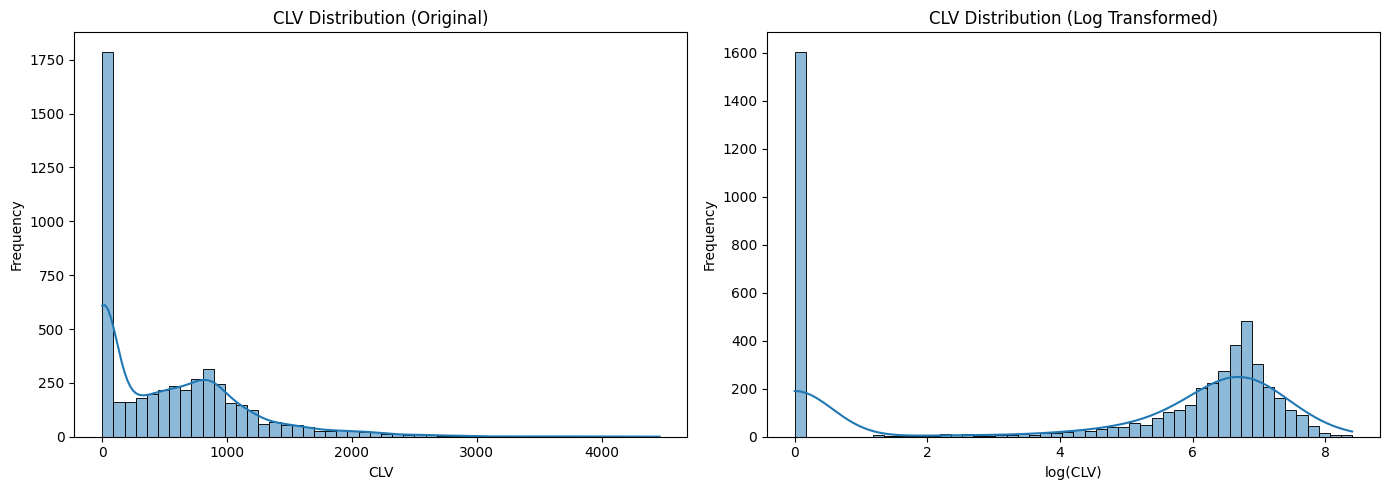

Original CLV Skewness: 1.4153
Log CLV Skewness: -0.5706
Customers with CLV = 0 (likely to churn): 1604
Percentage: 32.54%


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original CLV distribution
sns.histplot(x_train_original['CLV'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('CLV Distribution (Original)')
axes[0].set_xlabel('CLV')
axes[0].set_ylabel('Frequency')

# Log transformed CLV distribution
x_train_original['CLV_log'] = np.log1p(x_train_original['CLV'])
sns.histplot(x_train_original['CLV_log'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('CLV Distribution (Log Transformed)')
axes[1].set_xlabel('log(CLV)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print skewness
print(f"Original CLV Skewness: {x_train_original['CLV'].skew():.4f}")
print(f"Log CLV Skewness: {x_train_original['CLV_log'].skew():.4f}")

print(f"Customers with CLV = 0 (likely to churn): {(x_train_original['CLV'] == 0).sum()}")
print(f"Percentage: {(x_train_original['CLV'] == 0).mean() * 100:.2f}%")

Original CLV shows a skewness of 1.4153, confirming right skew.
32.54% of customers have CLV = 0, representing customers the model 
identifies as likely to churn imminently. Log transformation reduces 
skewness to -0.5706, which falls within the acceptable range for 
regression modeling. CLV_log will be used as the regression target.

<h3>CLV Calculated for test set</h3>

In [54]:
survival_probab = logisticModel.predict_proba(x_test_scaled)[:, 0]
x_test_original['predicted_remaining_tenure'] = (survival_probab * max_tenure) - x_test_original['tenure']

# Clip negative values to 0 (customer already exceeded expected lifetime)
x_test_original['predicted_remaining_tenure'] = x_test_original['predicted_remaining_tenure'].clip(lower=0)

# CLV
x_test_original['CLV'] = x_test_original['MonthlyCharges'] * x_test_original['predicted_remaining_tenure']
x_test_original['CLV_log'] = np.log1p(x_test_original['CLV'])

---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
- Which model performs best? By how much?
- What does R² = 0.55 actually mean in this context?
- Is RMSE or MAE more appropriate here? Why?

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


In [55]:
# your code here
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [56]:
# your code here
# top 10 features from logistic regression
top_10_features = [
    'Contract_Two year',
    'tenure',
    'InternetService_Fiber optic',
    'Contract_One year',
    'TotalCharges',
    'PaymentMethod_Electronic check',
    'StreamingMovies_Yes',
    'PaperlessBilling_Yes',
    'MonthlyCharges',
    'OnlineSecurity_Yes'
]

# Training data
df_train_reg = x_train_original[x_train_original['CLV'] > 0].copy()
y_train = df_train_reg['CLV_log']

# Test data
df_test_reg = x_test_original[x_test_original['CLV'] > 0].copy()
y_test = df_test_reg['CLV_log']


models = {
    'LinearRegression': LinearRegression(),
    'Ridge'           : Ridge(alpha=1.0),
    'Lasso'           : Lasso(alpha=0.1),
    'ElasticNet'      : ElasticNet(alpha=0.1, l1_ratio=0.5)
}

results = []



In [57]:
for name, reg_model in models.items():
    # Fit on train
    reg_model.fit(df_train_reg[top_10_features], y_train)
    
    # Predict on test
    y_pred = reg_model.predict(df_test_reg[top_10_features])
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MAE'  : round(mae, 4),
        'RMSE' : round(rmse, 4),
        'R2'   : round(r2, 4)
    })

results_df = pd.DataFrame(results)
print(results_df)

              Model     MAE    RMSE      R2
0  LinearRegression  0.4507  0.6202  0.5558
1             Ridge  0.4504  0.6200  0.5560
2             Lasso  0.6056  0.8072  0.2474
3        ElasticNet  0.5366  0.7283  0.3874


---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern


In [58]:
# your code here
ridgeModel = Ridge(alpha=1.0).fit(df_train_reg[top_10_features], y_train)
best_lin_reg_predict = ridgeModel.predict(df_test_reg[top_10_features])

In [59]:
residuals = best_lin_reg_predict - y_test

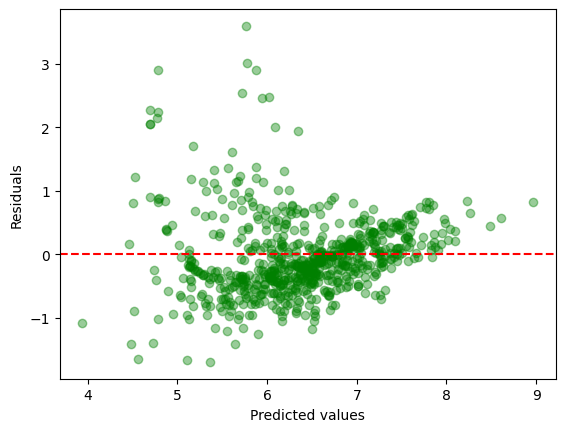

In [60]:
# your code here
plt.scatter(best_lin_reg_predict, residuals, alpha=0.4, color='g')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.show()

The residual plot reveals heteroscedasticity in the model. Residuals 
are more spread at lower predicted CLV values and tighter at higher 
predicted values, forming a funnel shape. This suggests the model 
underestimates low CLV customers more frequently. This is a known 
limitation of linear regression on derived targets such as CLV, where 
variance is not constant across the prediction range.

---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs


In [69]:
def try_at_alphas(alphas):
    coefs = []
    for alpha in alphas:
        try_model = Ridge(alpha=alpha, random_state=42)
        try_model.fit(df_train_reg[top_10_features], y_train)
        coefs.append(try_model.coef_)
    return coefs

alphas = [0.01, 0.1, 1, 10, 100]
coefs = try_at_alphas(alphas)


In [70]:
# your code here
coefs_df = pd.DataFrame(coefs, index=alphas, columns=top_10_features)
print(coefs_df)

        Contract_Two year    tenure  InternetService_Fiber optic  \
0.01             0.871514 -0.043736                    -1.218573   
0.10             0.870966 -0.043732                    -1.217951   
1.00             0.865521 -0.043692                    -1.211768   
10.00            0.814385 -0.043315                    -1.153603   
100.00           0.503875 -0.041190                    -0.793254   

        Contract_One year  TotalCharges  PaymentMethod_Electronic check  \
0.01             0.898603     -0.000038                       -0.453902   
0.10             0.898195     -0.000037                       -0.453877   
1.00             0.894136     -0.000036                       -0.453616   
10.00            0.855836     -0.000025                       -0.450798   
100.00           0.613324      0.000054                       -0.413327   

        StreamingMovies_Yes  PaperlessBilling_Yes  MonthlyCharges  \
0.01              -0.421665             -0.326534        0.022094   
0.

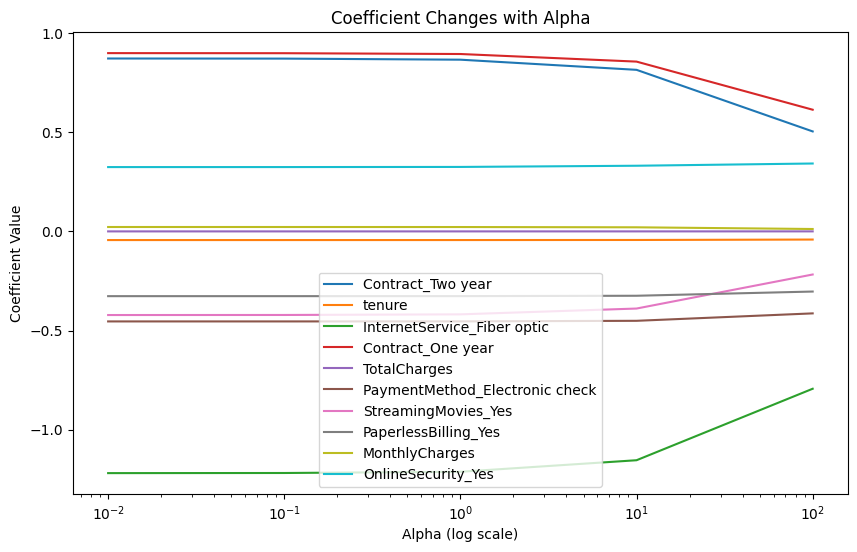

In [71]:
#visualize coefficient changes with alpha
plt.figure(figsize=(10, 6))
for feature in top_10_features:
    plt.plot(alphas, coefs_df[feature], label=feature)
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Coefficient Changes with Alpha')
plt.legend()
plt.show()

---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
- What is the mean and median CLV?
- What does CLV enable the business to do that binary prediction cannot?
- Why must you clip negative predicted tenure values to 0?

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


In [80]:
# your code here
pred_tenure_val_set = np.maximum(ridgeModel.predict(x_val_original[top_10_features]), 0)
clv_val_set = pred_tenure_val_set * x_val_original['MonthlyCharges']
clv_val_set.head()

6906    119.514263
6015    475.393390
2142    506.173060
2080    460.531943
6488    419.397703
Name: MonthlyCharges, dtype: float64

---

## 💬 Discussion

> **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
> **Your Lasso dropped several features. Is that a good outcome or a warning sign?**

---

# Block 5 — Evaluation Integrity + Leakage Demo

---

## Generalisation — Bias, Variance & Learning Curves

**Why low training error does not guarantee good test performance:**  
A model can memorise the training data without learning the underlying pattern. It fits noise, not signal.

| Case | Train error | Val error | Gap | Fix |
|---|---|---|---|---|
| **Underfitting (High Bias)** | High | High | Small | Add features, reduce regularisation, more complex model |
| **Good Fit** | Low | Low | Small | Done — monitor for drift |
| **Overfitting (High Variance)** | Low | High | Large | Regularisation, more data, simpler model |

---

## Validation Strategies

| Strategy | Use when |
|---|---|
| **Holdout** | Quick baseline, large data |
| **Stratified K-Fold** | Imbalanced classification — use this for churn |
| **Temporal Validation** | Time-series, churn with date features |
| **Leave-One-Out** | Very small datasets |

---

## 5.1 Cross-Validation

### Task:
Run stratified k-fold cross-validation on your best classifier. Compare CV AUC to holdout AUC.

### Questions:
- How does CV performance compare to holdout performance?
- What does high variance across CV folds tell you?
- Why should CV always be run on training data only?

### Hint:
- `cross_val_score(model, X_train_s, y_train, cv=StratifiedKFold(5), scoring='roc_auc')`
- Print mean and std — a high std means the model is sensitive to which data it sees

### Reference:
- StatQuest Cross-Validation: https://www.youtube.com/watch?v=fSytzGwwBVw


In [ ]:
# your code here

In [ ]:
# your code here

---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA


In [ ]:
# your code here

In [ ]:
# your code here

---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [ ]:
# Step 1: Record baseline metrics
# your code here

In [ ]:
# Step 2: Create and add the leakage feature
# your code here

In [ ]:
# Step 3: Retrain on the same split and record metrics
# your code here

In [ ]:
# Step 4: Show feature importances — does the leakage feature dominate?
# your code here

In [ ]:
# Step 5: Remove leakage feature, retrain, confirm metrics return to baseline
# your code here

In [ ]:
# Step 6: Summary table — Before / With Leakage / After Removal
# your code here

---

## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

---

# Block 6 — Production Decision

---

## The Model Card — A Production Commitment

A model card is what you write when you commit to deploying a model. If you cannot fill every field — you are not ready to ship.

| Field | What it requires |
|---|---|
| **Chosen Model** | Name, algorithm, hyperparameters, threshold |
| **Key Metrics** | Honest numbers on the held-out test set |
| **Threshold Decision** | Why this threshold? What does it cost if it is wrong? |
| **Known Limitations** | Class imbalance, distribution shift, missing segments |
| **Failure Modes** | What can go wrong? Leakage? Drift? Adversarial behaviour? |
| **Monitoring Plan** | What metric, how often, what triggers a retrain? |

---

## Are Linear Models Sufficient?

**Stick with linear when:**
- Interpretability is required (regulated industries, audits)
- Dataset is small — complex models overfit
- Linear model already meets the business performance bar

**Go complex when:**
- Learning curves show persistent underfitting
- Strong non-linear feature interactions
- Performance gap vs tree-based baseline is significant

---

## 6.1 Final Evaluation on Test Set

### Task:
Evaluate your chosen production model on the held-out test set.

### Questions:
- Do test set metrics match validation metrics? Why might they differ?
- Does your chosen threshold still make sense on the test set?

### Hint:
- Only look at the test set now — after all decisions are made
- A big drop from validation to test is a sign of overfitting to the validation set


In [ ]:
# your code here

In [ ]:
# your code here

---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | |
| **Chosen Regression Model** | |
| **Key Classification Metrics (test set)** | Precision: &nbsp; Recall: &nbsp; F1: &nbsp; PR-AUC: |
| **Key Regression Metrics (test set)** | MAE: &nbsp; RMSE: &nbsp; R²: |
| **Deployment Threshold** | |
| **Threshold Justification** | |
| **Known Limitations** | |
| **What Could Go Wrong in Production** | |
| **Monitoring Plan** | |
| **Are Linear Models Sufficient?** | |
| **Evidence for Your Decision** | |

---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What would trigger a retrain?**

---

# Final Reflection

## Answer the following:

### 1. Model Selection
- Which classifier performed best and why?
- Was there a case where a worse model on one metric was better on another? How did you resolve it?

---

### 2. Evaluation Choices
- Why did you choose the metrics you reported?
- What would have happened if you only reported accuracy?

---

### 3. Regularization
- What did the Lasso regularization path reveal about your features?
- When did you observe the biggest difference between Ridge and Lasso?

---

### 4. Leakage
- How large was the AUC inflation from the leakage feature?
- Could cross-validation alone have detected this leakage? Why or why not?

---

### 5. Improvements
- If you had more time, what would you try next?
- Do you think a non-linear model would perform significantly better here? What is your evidence?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying every decision with evidence from your experiments
- Explaining trade-offs honestly
- Demonstrating that you understand what the numbers mean, not just how to compute them

### Answer here:

---

# Summary

| Topic | Key Takeaway |
|---|---|
| **Problem Formulation** | X, y, hypothesis class, loss, metric — every model is a formal commitment |
| **Distributions & Loss** | The distribution of y determines your loss. Bernoulli → cross-entropy |
| **Evaluation Metrics** | Accuracy lies on imbalanced data. Use PR-AUC. Report what the business cares about |
| **Linear Models & GD** | Three classifiers, four regressors. Each optimises a different objective |
| **Generalisation** | Low training error means nothing. Learning curves tell the truth |
| **Regularization** | L1 is sparse. L2 is stable. Elastic Net is both. Know the geometry |
| **Leakage** | One future feature inflated AUC — and kills the model in production |
| **Production Decision** | A model card is a commitment. If you cannot fill it, you are not ready to ship |

---

## Next Week — Trees & Ensemble Models

Same dataset. Same question. **Can you beat your linear baseline?**
